In [1]:
"""
Adversarial validation on IEEE-CIS Fraud Detection:
- Class 0: train_transaction rows
- Class 1: test_transaction rows

Outputs:
1) ROC curve for adversarial classifier
2) Average LightGBM feature importance (horizontal bar chart)
"""

from pathlib import Path
import re

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import StratifiedKFold

In [2]:
DATA_DIR = Path("/ieee-fraud-detection")
NROWS = None          # e.g. 200000 for quick test
TOP_K_FEATURES = 50
RANDOM_STATE = 42

In [3]:
def transform_d_columns(df: pd.DataFrame) -> pd.DataFrame:
    if "TransactionDT" not in df.columns:
        return df

    d_cols = [c for c in df.columns if c.startswith("D") and c[1:].isdigit()]
    transaction_day = np.floor(df["TransactionDT"] / (24*60*60))
    for col in d_cols:
        df[col] = transaction_day - df[col]
    return df

In [4]:
train_path = DATA_DIR / "train_transaction.csv"
test_path = DATA_DIR / "test_transaction.csv"

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(f"Missing CSVs:\n- {train_path}\n- {test_path}")

all_cols = pd.read_csv(train_path, nrows=0).columns.tolist()
candidate_cols = [c for c in all_cols if c != "isFraud"]
feature_cols = candidate_cols[:54]

train_df = pd.read_csv(train_path, usecols=feature_cols, nrows=NROWS)
test_df = pd.read_csv(test_path, usecols=feature_cols, nrows=NROWS)

In [5]:
print(f"All cols: {all_cols}")

All cols: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80',

In [6]:
print(f"Feature columns: {feature_cols}")

Feature columns: ['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [7]:
train_df

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,86400,68.50,W,13926,NaN,150.0,discover,142.0,credit,...,0.0,T,T,T,M2,F,T,NaN,NaN,NaN
1,2987001,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,credit,...,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,2987002,86469,59.00,W,4663,490.0,150.0,visa,166.0,debit,...,315.0,T,T,T,M0,F,F,F,F,F
3,2987003,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,debit,...,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,2987004,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,...,56.0,T,T,T,M0,T,F,F,F,T
590536,3577536,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,debit,...,0.0,T,F,F,M0,F,T,F,F,F
590537,3577537,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,debit,...,0.0,T,F,F,NaN,NaN,T,NaN,NaN,NaN
590538,3577538,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,debit,...,22.0,T,T,T,M0,F,T,NaN,NaN,NaN


In [8]:
test_df

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,3663549,18403224,31.950,W,10409,111.0,150.0,visa,226.0,debit,...,409.0,T,T,F,NaN,NaN,F,T,T,T
1,3663550,18403263,49.000,W,4272,111.0,150.0,visa,226.0,debit,...,634.0,T,F,F,M0,NaN,F,NaN,NaN,NaN
2,3663551,18403310,171.000,W,4476,574.0,150.0,visa,226.0,debit,...,97.0,T,T,F,M0,F,F,F,F,F
3,3663552,18403310,284.950,W,10989,360.0,150.0,visa,166.0,debit,...,242.0,T,T,T,NaN,NaN,T,NaN,NaN,NaN
4,3663553,18403317,67.950,W,18018,452.0,150.0,mastercard,117.0,debit,...,22.0,T,T,T,NaN,NaN,F,F,T,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506686,4170235,34214279,94.679,C,13832,375.0,185.0,mastercard,224.0,debit,...,0.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN
506687,4170236,34214287,12.173,C,3154,408.0,185.0,mastercard,224.0,debit,...,16.0,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN
506688,4170237,34214326,49.000,W,16661,490.0,150.0,visa,226.0,debit,...,0.0,T,T,T,M0,F,F,F,T,T
506689,4170238,34214337,202.000,W,16621,516.0,150.0,mastercard,224.0,debit,...,0.0,T,T,T,M0,F,F,F,F,F


In [9]:
# Cell 5: Build adversarial dataset + preprocessing
train_df["is_test"] = 0
test_df["is_test"] = 1
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

y = df["is_test"].astype("int8")
X = df.drop(columns=["is_test"])

X = transform_d_columns(X)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    X[col], _ = pd.factorize(X[col].astype(str), sort=True)

X = X.fillna(-999)

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_65842/1526638967.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [10]:
print(f"Categorical columns: {cat_cols}")

Categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [11]:
X

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,86400,68.500,4,13926,-999.0,150.0,1,142.0,1,...,1.0,1,1,1,2,0,1,-1,-1,-1
1,2987001,86401,29.000,4,2755,404.0,150.0,2,102.0,1,...,1.0,-1,-1,-1,0,1,1,-1,-1,-1
2,2987002,86469,59.000,4,4663,490.0,150.0,3,166.0,2,...,-314.0,1,1,1,0,0,0,0,0,0
3,2987003,86499,50.000,4,18132,567.0,150.0,2,117.0,2,...,-110.0,-1,-1,-1,0,1,0,-1,-1,-1
4,2987004,86506,50.000,1,4497,514.0,150.0,2,102.0,1,...,-999.0,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097226,4170235,34214279,94.679,0,13832,375.0,185.0,2,224.0,2,...,395.0,-1,-1,-1,2,-1,-1,-1,-1,-1
1097227,4170236,34214287,12.173,0,3154,408.0,185.0,2,224.0,2,...,379.0,-1,-1,-1,2,-1,-1,-1,-1,-1
1097228,4170237,34214326,49.000,4,16661,490.0,150.0,3,226.0,2,...,395.0,1,1,1,0,0,0,0,1,1
1097229,4170238,34214337,202.000,4,16621,516.0,150.0,2,224.0,2,...,395.0,1,1,1,0,0,0,0,0,0


In [12]:
y

0          0
1          0
2          0
3          0
4          0
          ..
1097226    1
1097227    1
1097228    1
1097229    1
1097230    1
Name: is_test, Length: 1097231, dtype: int8

In [13]:
# Cell 6: 5-fold adversarial validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.zeros(len(X), dtype="float32")
importances = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42 + fold,
        n_jobs=-1,
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)],
    )

    oof_pred[va_idx] = model.predict_proba(X_va)[:, 1]
    importances.append(model.feature_importances_)

[LightGBM] [Info] Number of positive: 405352, number of negative: 472432
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9349
[LightGBM] [Info] Number of data points in the train set: 877784, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461790 -> initscore=-0.153138
[LightGBM] [Info] Start training from score -0.153138
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Adversarial ROC-AUC: 0.999976


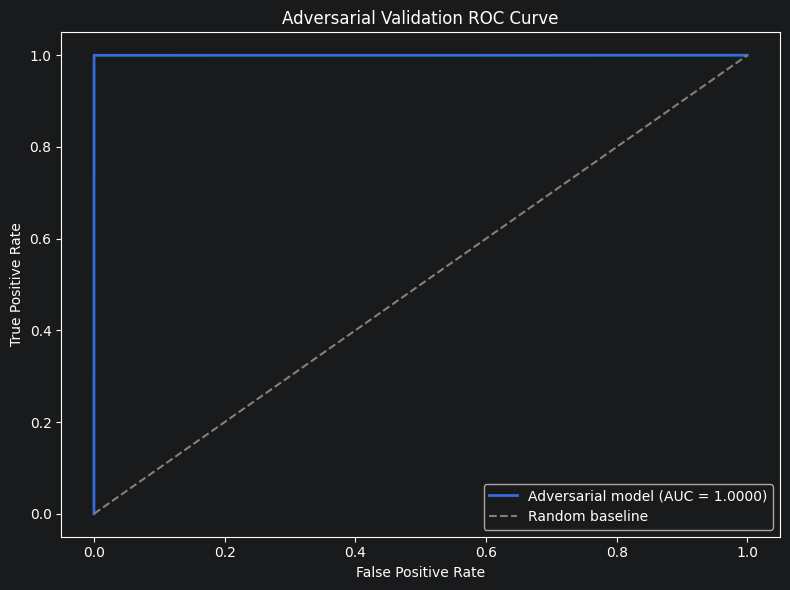

In [14]:
# Cell 7: ROC curve
fpr, tpr, _ = roc_curve(y, oof_pred)
roc_auc = auc(fpr, tpr)
print(f"Adversarial ROC-AUC: {roc_auc:.6f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f"Adversarial model (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Adversarial Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_65842/3432994636.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=imp_df, x="importance", y="feature", palette="Spectral")


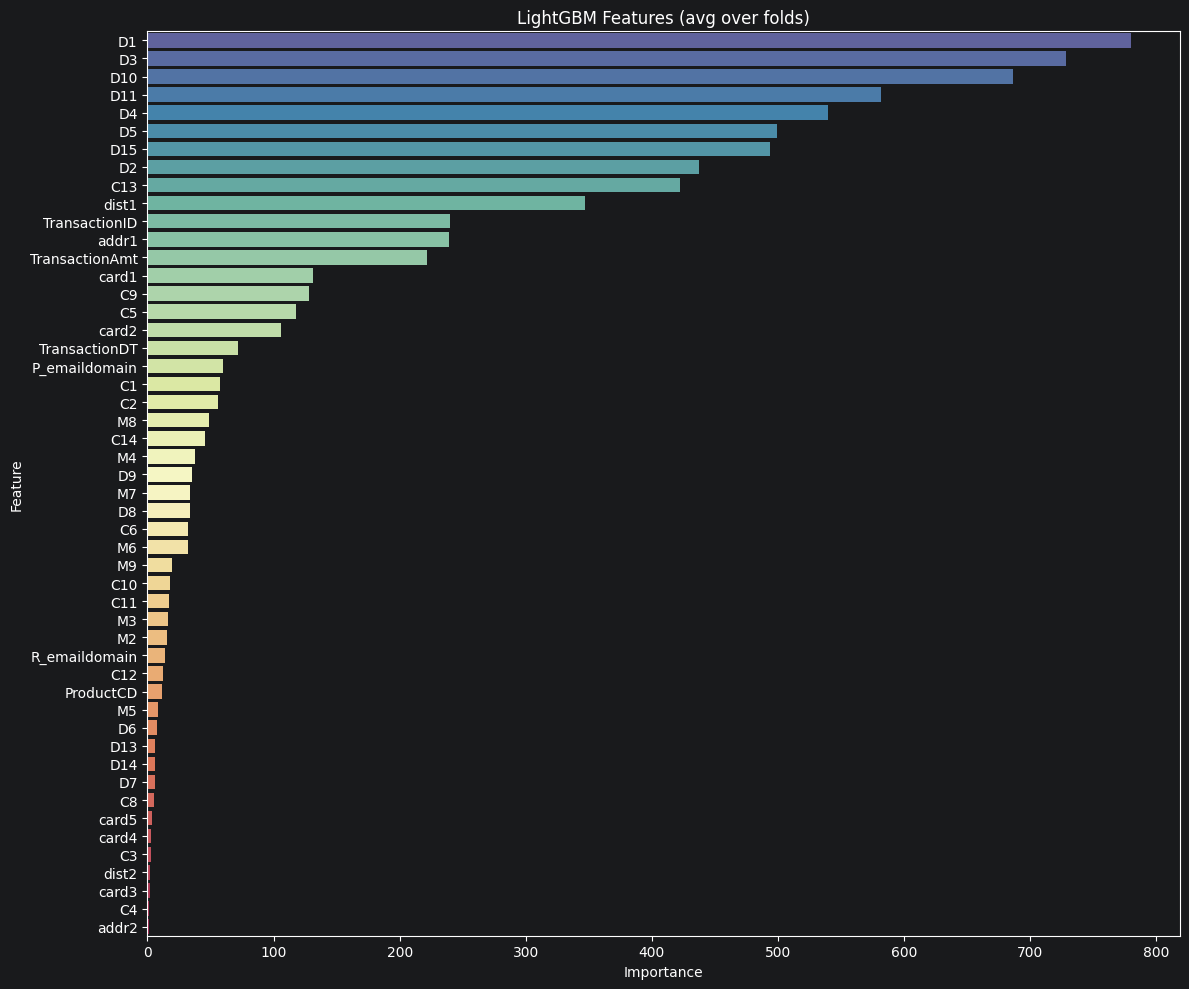

In [15]:
# Cell 8: Feature importance plot
imp = np.mean(np.vstack(importances), axis=0)
imp_df = (
    pd.DataFrame({"feature": X.columns, "importance": imp})
    .sort_values("importance", ascending=False)
    .head(TOP_K_FEATURES)
)
imp_df = imp_df.iloc[::-1]

plt.figure(figsize=(12, 10))
ax = sns.barplot(data=imp_df, x="importance", y="feature", palette="Spectral")
ax.invert_yaxis()  # flip vertically
plt.title("LightGBM Features (avg over folds)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [16]:
# Cell 9: Select only V columns and load data
if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(f"Missing CSVs:\n- {train_path}\n- {test_path}")

all_cols = pd.read_csv(train_path, nrows=0).columns.tolist()
v_cols = [c for c in all_cols if re.fullmatch(r"V\d+", c)]
v_cols = sorted(v_cols, key=lambda x: int(x[1:]))

if not v_cols:
    raise ValueError("No V columns found.")

train_df = pd.read_csv(train_path, usecols=v_cols, nrows=NROWS)
test_df = pd.read_csv(test_path, usecols=v_cols, nrows=NROWS)

print(f"Loaded {len(v_cols)} V columns")
print(f"train shape: {train_df.shape}, test shape: {test_df.shape}")

Loaded 339 V columns
train shape: (590540, 339), test shape: (506691, 339)


In [17]:
# Cell 10: Build adversarial dataset
train_df["is_test"] = 0
test_df["is_test"] = 1
df_adv = pd.concat([train_df, test_df], axis=0, ignore_index=True)

y = df_adv["is_test"].astype("int8")
X = df_adv.drop(columns=["is_test"]).copy()

# Safety: handle any object/category (usually V columns are numeric)
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    X[col], _ = pd.factorize(X[col].astype(str), sort=True)

X = X.fillna(-999)
print("X shape:", X.shape)

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_65842/891704585.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["is_test"] = 0
/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_65842/891704585.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["is_test"] = 1


X shape: (1097231, 339)


In [18]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097226,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1097227,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1097228,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1097229,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [19]:
# Cell 11: 5-fold adversarial validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_pred = np.zeros(len(X), dtype="float32")
importances = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)],
    )

    oof_pred[va_idx] = model.predict_proba(X_va)[:, 1]
    importances.append(model.feature_importances_)

[LightGBM] [Info] Number of positive: 405352, number of negative: 472432
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.483606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27824
[LightGBM] [Info] Number of data points in the train set: 877784, number of used features: 339
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461790 -> initscore=-0.153138
[LightGBM] [Info] Start training from score -0.153138
[LightGBM] [Info] Number of positive: 405353, number of negative: 472432
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.437001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28394
[LightGBM] [Info] Number of data points in the train set: 877785, number of used features: 338
[LightGB

Adversarial ROC-AUC (V columns only): 0.765935


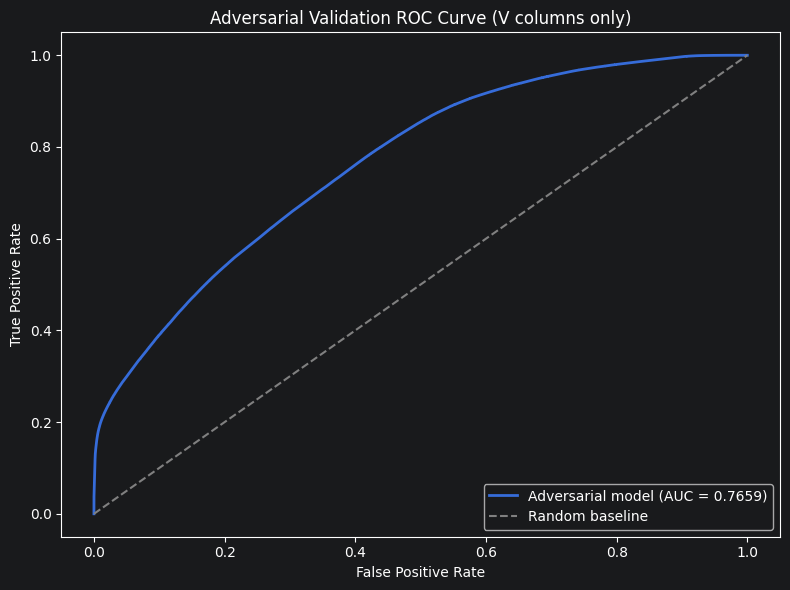

In [26]:
# Cell 13: ROC-AUC + ROC curve
fpr, tpr, _ = roc_curve(y, oof_pred)
roc_auc = auc(fpr, tpr)
print(f"Adversarial ROC-AUC (V columns only): {roc_auc:.6f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f"Adversarial model (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Adversarial Validation ROC Curve (V columns only)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

/var/folders/qh/10rj2tgd6dld_075lmzprz_h0000gn/T/ipykernel_65842/3171579461.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=imp_df, x="importance", y="feature", palette="Spectral")


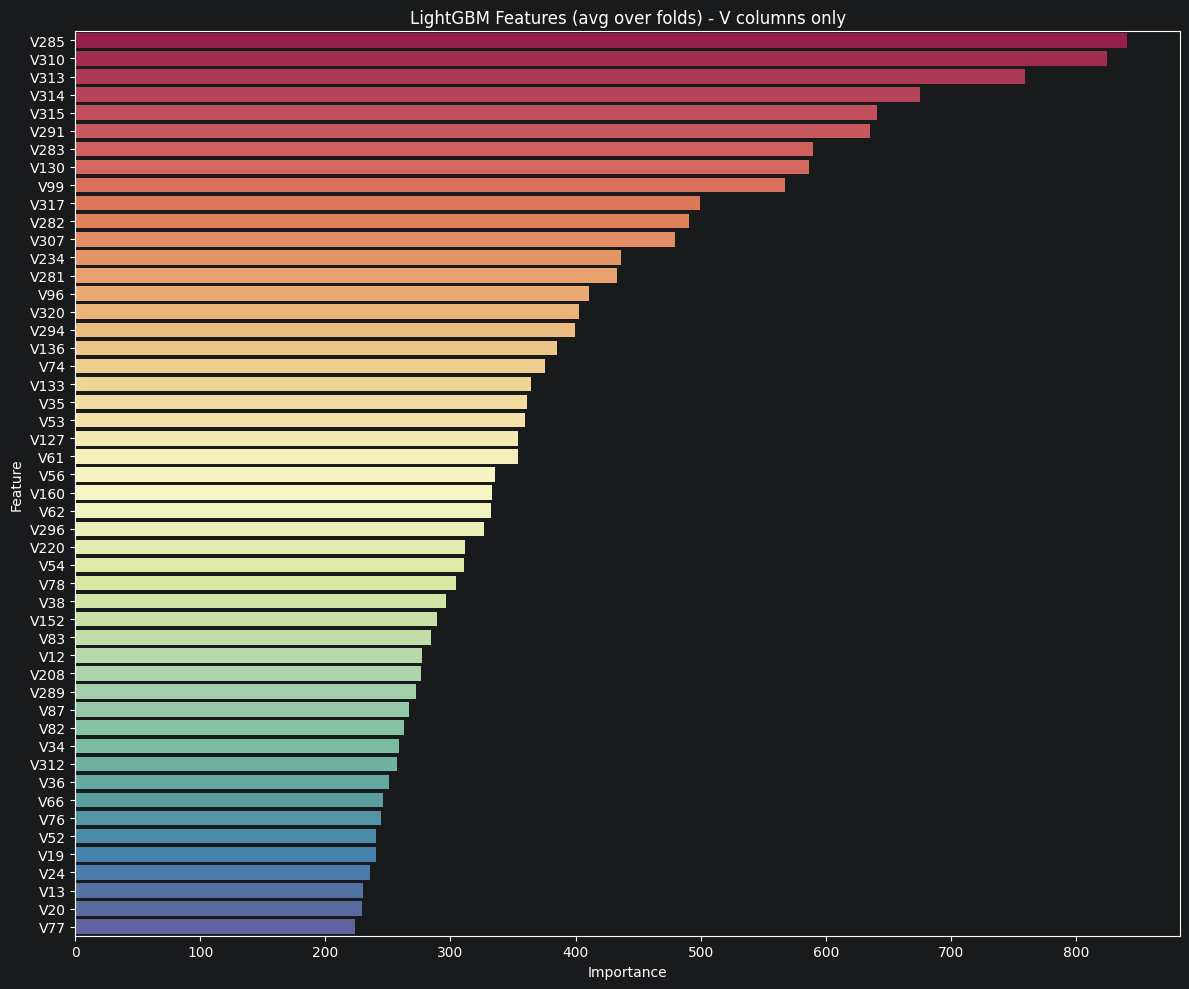

In [27]:
# Cell 14: Feature importance (flipped upside down)
imp = np.mean(np.vstack(importances), axis=0)
imp_df = (
    pd.DataFrame({"feature": X.columns, "importance": imp})
    .sort_values("importance", ascending=False)
    .head(TOP_K_FEATURES)
)

plt.figure(figsize=(12, 10))
ax = sns.barplot(data=imp_df, x="importance", y="feature", palette="Spectral")
# ax.invert_yaxis()  # upside down
plt.title("LightGBM Features (avg over folds) - V columns only")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [20]:
def make_corr(Vs, Vtitle=''):
    plt.figure(figsize=(12,10))
    sns.heatmap(train_df[Vs].corr(), cmap='RdBu_r', annot=True, center=0.0)
    plt.title(Vtitle if Vtitle else f"{Vs[0]} - {Vs[-1]}", fontsize=14)
    plt.show()

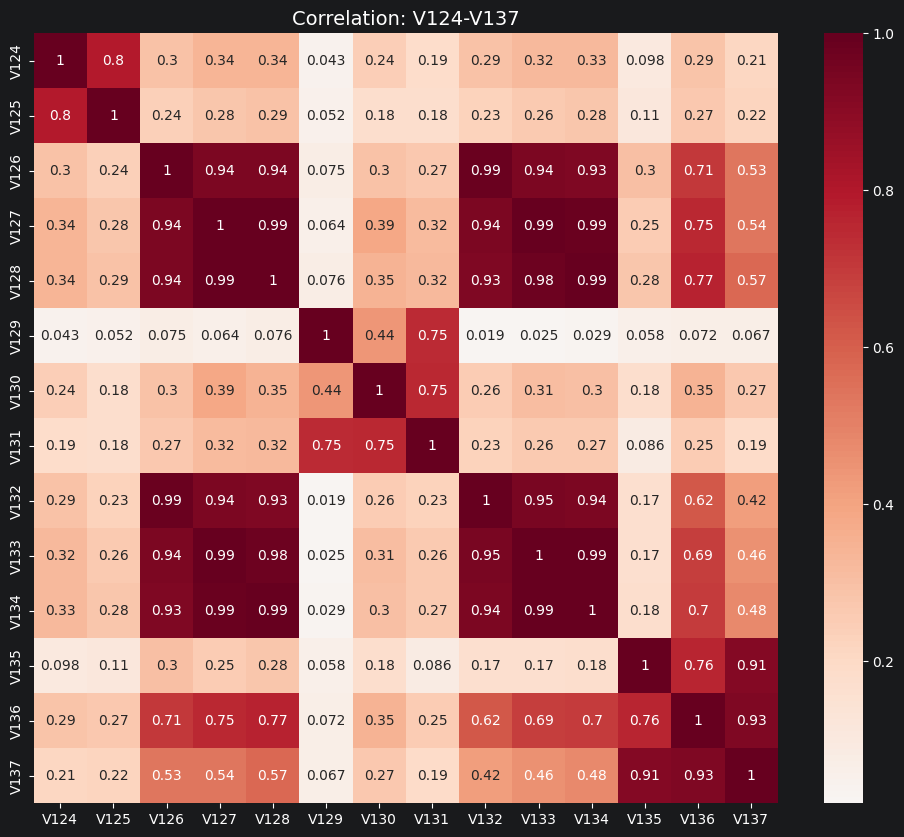

In [21]:
Vs = [f"V{i}" for i in range(124, 138)]  # V124 ... V137
Vtitle = "Correlation: V124-V137"

make_corr(Vs, Vtitle)

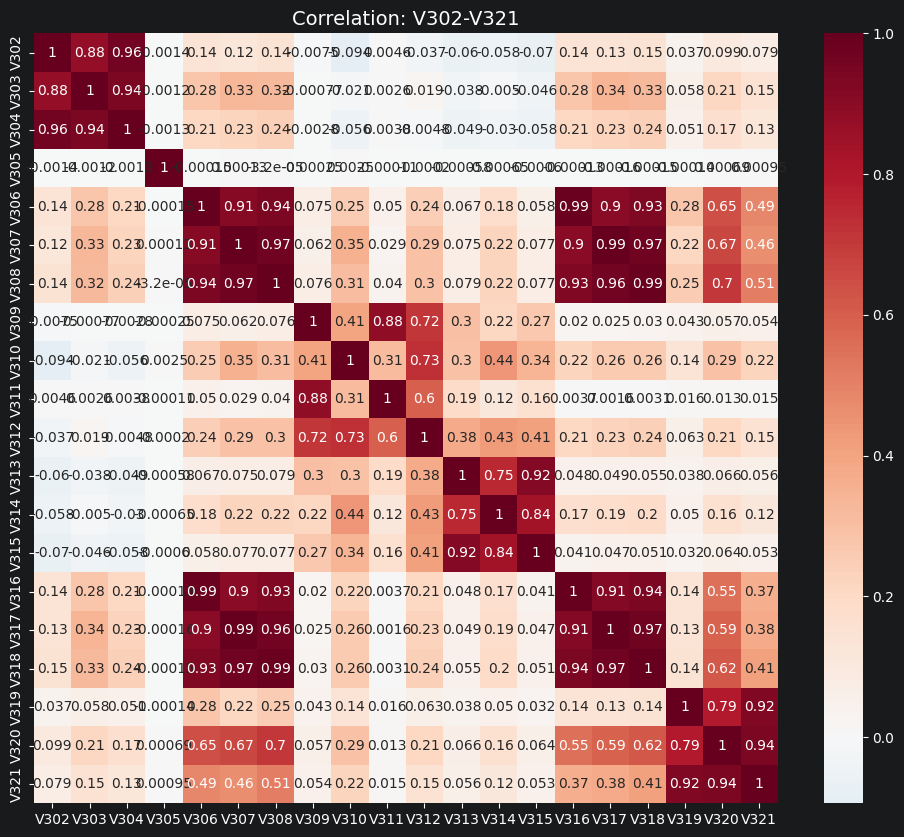

In [22]:
Vs = [f"V{i}" for i in range(302, 322)]  # V302 ... V322
Vtitle = "Correlation: V302-V321"

make_corr(Vs, Vtitle)